<a href="https://colab.research.google.com/github/victorialms/Ex2PandasEssencial/blob/main/atividade_pratica_aula2_dataviz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 2: Pandas Essencial

Nesta atividade, você vai aplicar os conceitos da aula para explorar um dataset de vendas, fazer um **check-up inicial**, selecionar colunas relevantes, criar **filtros de negócio**, construir **rankings** e transformar resultados em **interpretação gerencial**.

**Dataset:** `vendas_dataviz_aula2.csv`

## Objetivos da atividade
- Ler e inspecionar um dataset com Pandas
- Entender a diferença entre DataFrame e Series
- Verificar tamanho, tipos e possíveis problemas de qualidade
- Selecionar apenas as colunas importantes para análise
- Filtrar dados com uma e múltiplas condições
- Criar rankings com `sort_values`, `nlargest` e `nsmallest`
- Interpretar resultados em linguagem de negócio


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para a atividade.
- `pandas`
- `numpy`
- `matplotlib.pyplot` (caso queira visualizar resultados)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Leitura do dataset

Leia o arquivo `vendas_dataviz_aula2.csv` em um DataFrame chamado `df`.
Depois, exiba as 5 primeiras linhas.


In [ ]:
df = pd.read_csv('vendas_dataviz_aula2.csv')
df.head()

,data,produto,categoria,estado,canal,vendas,quantidade,preco_unitario,custo,lucro,avaliacao_cliente
0,2024-04-12,Mouse Gamer,Periféricos,RJ,Marketplace,562.26,3,187.42,97.70,269.16,4.6
1,2024-05-01,Headset,Áudio,ES,MarketPlace,1124.08,4,281.02,144.77,545.00,3.8
2,2024-10-03,Teclado Mecânico,Periféricos,SP,Marketplace,2515.73,7,359.39,153.66,1440.11,4.3
3,2024-07-06,Webcam HD,Periféricos,SP,Marketplace,596.76,3,198.92,125.09,221.49,4.3
4,2024-02-24,Smartwatch,Telefonia,RJ,Loja Física,3908.08,4,977.02,666.26,1243.04,4.4


## 3. Anatomia dos dados: DataFrame e Series

### Questão 1
Explique, com base no que foi visto em aula:
1. O que é um **DataFrame**?
2. O que é uma **Series**?
3. Mostre no código uma coluna isolada do DataFrame.

#Resposta:

#### 1. DataFrame é uma estrutura de dados em formato de tabela, com linhas e colunas, como se fosse uma planilha.
#### 2. Series é uma única coluna do DataFrame, ou seja, um conjunto de dados unidimensional.

#### 3. No exemplo abaixo, ao selecionar a coluna 'produto', o retorno é uma Series.


In [ ]:
# Exemplo: selecione uma única coluna e observe o tipo retornado
serie_produto = df['produto']
type(serie_produto), serie_produto.head()

(pandas.core.series.Series,
 0         Mouse Gamer
 1             Headset
 2    Teclado Mecânico
 3           Webcam HD
 4          Smartwatch
 Name: produto, dtype: object)

## 4. Check-up inicial do dataset

Um analista profissional sempre começa verificando o tamanho, a estrutura e a qualidade inicial dos dados.

### Questão 2
Use:
- `df.shape`
- `df.info()`
- `df.dtypes`

Depois responda:
1. Quantas linhas e colunas existem?
2. Quais colunas parecem numéricas?
3. Há sinais de valores ausentes?
4. Existe alguma coluna com tipo inadequado?

#Resposta:

#### 1. O dataset possui 450 linhas e 11 colunas.
#### 2. As colunas que parecem numéricas são: quantidade, preco_unitario, custo, lucro e avaliacao_cliente.
#### 3. Sim, há sinais de valores ausentes, pois as colunas 'estado' e 'avaliacao_cliente' possuem valores nulos.
#### 4. Sim, a coluna 'vendas' está como object, mas deveria ser numérica, indicando tipo inadequado.

In [ ]:
df.shape

(450, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data               450 non-null    object 
 1   produto            450 non-null    object 
 2   categoria          450 non-null    object 
 3   estado             449 non-null    object 
 4   canal              450 non-null    object 
 5   vendas             450 non-null    object 
 6   quantidade         450 non-null    int64  
 7   preco_unitario     450 non-null    float64
 8   custo              450 non-null    float64
 9   lucro              450 non-null    float64
 10  avaliacao_cliente  448 non-null    float64
dtypes: float64(4), int64(1), object(6)
memory usage: 38.8+ KB


In [ ]:
df.dtypes

,0
data,object
produto,object
categoria,object
estado,object
canal,object
vendas,object
quantidade,int64
preco_unitario,float64
custo,float64
lucro,float64


## 5. Inspeção de problemas de qualidade

Na aula, vimos que dashboards podem falhar por causa de dados mal preparados.

### Questão 3
Investigue:
- valores nulos
- categorias inconsistentes
- números armazenados como texto
- valores infinitos

Dica:
- `df.isna().sum()`
- `df['canal'].value_counts(dropna=False)`
- `df['estado'].value_counts(dropna=False)`
- `np.isinf(...)`


#Resposta

### Investigando valores nulos:

#### Existem valores nulos nas colunas 'estado' e 'avaliacao_cliente'.

#### Há categorias inconsistentes na coluna 'canal', como 'Marketplace', 'MarketPlace', 'online' e 'ONLINE', que representam a mesma informação mas estão escritas de formas diferentes.

#### Também há inconsistência na coluna 'estado', como 'RJ' e 'rj'.

#### A coluna 'vendas' está armazenada como texto (object), quando deveria ser numérica.

#### Foram encontrados valores infinitos na coluna 'lucro', o que pode prejudicar análises.

In [ ]:
df.isna().sum()

,0
data,0
produto,0
categoria,0
estado,1
canal,0
vendas,0
quantidade,0
preco_unitario,0
custo,0
lucro,0


In [ ]:
df['canal'].value_counts(dropna=False)

,count
canal,
Marketplace,152
Online,148
Loja Física,147
MarketPlace,1
online,1
ONLINE,1


In [ ]:
df['estado'].value_counts(dropna=False)

,count
estado,
ES,62
SP,52
BA,52
GO,49
PE,48
SC,42
MG,39
RS,38
RJ,36


In [ ]:
# Verifique se há valores infinitos na coluna lucro
pd.Series(np.isinf(pd.to_numeric(df['lucro'], errors='coerce'))).value_counts(dropna=False)

,count
lucro,
False,448
True,2


## 6. Selecionando o que importa

Nem toda análise precisa de todas as colunas. Vamos criar um recorte mais focado para responder perguntas de negócio.

### Questão 4
Crie um novo DataFrame chamado `df_dash` contendo apenas as colunas:
- `data`
- `estado`
- `canal`
- `produto`
- `categoria`
- `vendas`
- `lucro`

Use `.copy()` para evitar problemas futuros.


In [ ]:
#Resposta:

cols_dashboard = ['data', 'estado', 'canal', 'produto', 'categoria', 'vendas', 'lucro']
df_dash = df[cols_dashboard].copy()
df_dash.head()

,data,estado,canal,produto,categoria,vendas,lucro
0,2024-04-12,RJ,Marketplace,Mouse Gamer,Periféricos,562.26,269.16
1,2024-05-01,ES,MarketPlace,Headset,Áudio,1124.08,545.00
2,2024-10-03,SP,Marketplace,Teclado Mecânico,Periféricos,2515.73,1440.11
3,2024-07-06,SP,Marketplace,Webcam HD,Periféricos,596.76,221.49
4,2024-02-24,RJ,Loja Física,Smartwatch,Telefonia,3908.08,1243.04


In [ ]:
cols_dashboard = ['data', 'estado', 'canal', 'produto', 'categoria', 'vendas', 'lucro']
df_dash = df[cols_dashboard].copy()
df_dash.head()

,data,estado,canal,produto,categoria,vendas,lucro
0,2024-04-12,RJ,Marketplace,Mouse Gamer,Periféricos,562.26,269.16
1,2024-05-01,ES,MarketPlace,Headset,Áudio,1124.08,545.00
2,2024-10-03,SP,Marketplace,Teclado Mecânico,Periféricos,2515.73,1440.11
3,2024-07-06,SP,Marketplace,Webcam HD,Periféricos,596.76,221.49
4,2024-02-24,RJ,Loja Física,Smartwatch,Telefonia,3908.08,1243.04


## 7. Preparação mínima para análise

Algumas colunas podem precisar de ajuste antes de ordenar e agregar.

### Questão 5
1. Converta a coluna `data` para formato de data.
2. Crie uma coluna `mes` a partir da data.
3. Tente converter `vendas` para numérico, tratando possíveis textos.
4. Crie uma coluna chamada `vendas_num`.


In [ ]:
#Resposta:

df_dash['data'] = pd.to_datetime(df_dash['data'], errors='coerce')
df_dash['mes'] = df_dash['data'].dt.to_period('M')

vendas_limpa = (
    df_dash['vendas']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)

df_dash['vendas_num'] = pd.to_numeric(vendas_limpa, errors='coerce')
df_dash.head()

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
0,2024-04-12,RJ,Marketplace,Mouse Gamer,Periféricos,562.26,269.16,2024-04,56226.0
1,2024-05-01,ES,MarketPlace,Headset,Áudio,1124.08,545.00,2024-05,112408.0
2,2024-10-03,SP,Marketplace,Teclado Mecânico,Periféricos,2515.73,1440.11,2024-10,251573.0
3,2024-07-06,SP,Marketplace,Webcam HD,Periféricos,596.76,221.49,2024-07,59676.0
4,2024-02-24,RJ,Loja Física,Smartwatch,Telefonia,3908.08,1243.04,2024-02,390808.0


In [ ]:
df_dash['data'] = pd.to_datetime(df_dash['data'], errors='coerce')
df_dash['mes'] = df_dash['data'].dt.to_period('M')

# Limpeza simples para a coluna vendas (remove símbolo R$, espaços e troca vírgula decimal)
vendas_limpa = (
    df_dash['vendas']
    .astype(str)
    .str.replace('R\$', '', regex=True)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)

df_dash['vendas_num'] = pd.to_numeric(vendas_limpa, errors='coerce')
df_dash.head()

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_664/1170284534.py:8: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('R\$', '', regex=True)


,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
0,2024-04-12,RJ,Marketplace,Mouse Gamer,Periféricos,562.26,269.16,2024-04,56226.0
1,2024-05-01,ES,MarketPlace,Headset,Áudio,1124.08,545.00,2024-05,112408.0
2,2024-10-03,SP,Marketplace,Teclado Mecânico,Periféricos,2515.73,1440.11,2024-10,251573.0
3,2024-07-06,SP,Marketplace,Webcam HD,Periféricos,596.76,221.49,2024-07,59676.0
4,2024-02-24,RJ,Loja Física,Smartwatch,Telefonia,3908.08,1243.04,2024-02,390808.0


## 8. Filtragem simples: recorte de negócio

Na aula, vimos o exemplo de filtrar apenas o estado do Rio de Janeiro.

### Questão 6
Crie um DataFrame `df_rj` contendo apenas registros do estado `RJ`.
Depois responda:
1. Quantos registros existem nesse recorte?
2. Qual a soma de vendas no RJ?


#Resposta:

#### Existem 36 registros referentes ao estado do RJ.

#### A soma total de vendas no RJ é de 13.161.085.

#### Isso mostra o volume financeiro gerado nesse estado, sendo possível avaliar sua importância para o negócio.

In [ ]:
df_rj = df_dash[df_dash['estado'] == 'RJ']
df_rj.shape, df_rj['vendas_num'].sum()

((36, 9), np.float64(13161085.0))

## 9. Filtragem com múltiplas condições

Agora faça um recorte mais profissional: apenas vendas do estado do RJ no canal Online.

### Questão 7
Faça esse filtro de duas formas:
1. Usando operadores lógicos com `&`
2. Usando `query()`


#Resposta:

#### As duas formas de filtro retornam o mesmo resultado.

#### Esse recorte permite analisar especificamente as vendas online no RJ, ajudando a entender o desempenho desse canal em um estado específico.

In [ ]:
df_rj_online = df_dash[(df_dash['estado'] == 'RJ') & (df_dash['canal'] == 'Online')]
df_rj_online.head()

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
114,2024-10-26,RJ,Online,Mouse Gamer,Periféricos,378.4,185.94,2024-10,3784.0
173,2024-04-12,RJ,Online,Webcam HD,Periféricos,924.48,418.04,2024-04,92448.0
211,2024-12-31,RJ,Online,Caixa de Som,Áudio,3305.2,1361.44,2024-12,33052.0
222,2024-12-17,RJ,Online,Teclado Mecânico,Periféricos,1996.05,1105.55,2024-12,199605.0
243,2024-04-23,RJ,Online,Tablet Plus,Telefonia,10065.8,2142.15,2024-04,100658.0


In [ ]:
df_rj_online_q = df_dash.query("estado == 'RJ' and canal == 'Online'")
df_rj_online_q.head()

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
114,2024-10-26,RJ,Online,Mouse Gamer,Periféricos,378.4,185.94,2024-10,3784.0
173,2024-04-12,RJ,Online,Webcam HD,Periféricos,924.48,418.04,2024-04,92448.0
211,2024-12-31,RJ,Online,Caixa de Som,Áudio,3305.2,1361.44,2024-12,33052.0
222,2024-12-17,RJ,Online,Teclado Mecânico,Periféricos,1996.05,1105.55,2024-12,199605.0
243,2024-04-23,RJ,Online,Tablet Plus,Telefonia,10065.8,2142.15,2024-04,100658.0


## 10. Priorização: rankings

Gestores raramente leem tabelas enormes. Eles querem os **Top N**.

### Questão 8
Gere:
1. Os 10 registros com maior valor de `vendas_num`
2. Os 10 registros com maior `lucro`
3. Os 5 registros com menor `lucro`

Observe se aparece algum valor suspeito.


#Resposta:

####1. Os maiores valores de vendas estão concentrados principalmente em produtos como Notebook Pro, indicando alto valor agregado.
####2. No ranking de lucro, aparecem valores "inf", o que é suspeito e indica erro nos dados.
####3. Os menores lucros são valores muito baixos, mostrando vendas com pouca margem, o que pode não ser interessante para o negócio.

In [ ]:
top10_vendas = df_dash.sort_values('vendas_num', ascending=False).head(10)
top10_vendas

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
321,2024-08-18,SP,Loja Física,Notebook Pro,Informática,36140.72,10319.12,2024-08,3614072.0
183,2024-12-14,ES,Online,Notebook Pro,Informática,33212.83,13556.90,2024-12,3321283.0
56,2024-09-06,PE,Online,Notebook Pro,Informática,27867.72,9411.00,2024-09,2786772.0
319,2024-05-08,SC,Marketplace,Notebook Pro,Informática,21573.95,6869.60,2024-05,2157395.0
132,2024-08-05,PR,Loja Física,Notebook Pro,Informática,20352.96,8103.88,2024-08,2035296.0
387,2024-12-26,ES,Online,Tablet Plus,Telefonia,19061.82,5200.11,2024-12,1906182.0
74,2024-10-01,PR,Loja Física,Notebook Pro,Informática,18782.88,5744.80,2024-10,1878288.0
245,2024-12-26,SP,Marketplace,Smartphone X,Telefonia,18417.28,3773.84,2024-12,1841728.0
216,2024-07-22,SC,Online,Notebook Pro,Informática,17715.88,5747.00,2024-07,1771588.0
368,2024-05-29,SP,Online,Smartphone X,Telefonia,17631.48,5392.08,2024-05,1763148.0


In [ ]:
# Primeiro garantimos que lucro esteja numérico
df_dash['lucro_num'] = pd.to_numeric(df_dash['lucro'], errors='coerce')

top10_lucro = df_dash.nlargest(10, 'lucro_num')
top10_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
199,2024-02-06,ES,Online,Caixa de Som,Áudio,792.12,inf,2024-02,79212.0,inf
449,2024-06-10,SP,Marketplace,Teclado Mecânico,Periféricos,1818.06,inf,2024-06,181806.0,inf
183,2024-12-14,ES,Online,Notebook Pro,Informática,33212.83,13556.90,2024-12,3321283.0,13556.90
321,2024-08-18,SP,Loja Física,Notebook Pro,Informática,36140.72,10319.12,2024-08,3614072.0,10319.12
56,2024-09-06,PE,Online,Notebook Pro,Informática,27867.72,9411.00,2024-09,2786772.0,9411.00
442,2024-02-21,PR,Loja Física,Notebook Pro,Informática,19782.0,8546.28,2024-02,197820.0,8546.28
132,2024-08-05,PR,Loja Física,Notebook Pro,Informática,20352.96,8103.88,2024-08,2035296.0,8103.88
319,2024-05-08,SC,Marketplace,Notebook Pro,Informática,21573.95,6869.60,2024-05,2157395.0,6869.60
110,2024-06-28,BA,Loja Física,Smartphone X,Telefonia,16138.55,6519.65,2024-06,1613855.0,6519.65
109,2024-09-20,PE,Marketplace,Tablet Plus,Telefonia,14602.02,6151.92,2024-09,1460202.0,6151.92


In [ ]:
bottom5_lucro = df_dash.nsmallest(5, 'lucro_num')
bottom5_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
415,2024-10-11,MG,Loja Física,Mouse Gamer,Periféricos,158.6,60.58,2024-10,1586.0,60.58
273,2024-09-15,ES,Online,Mouse Gamer,Periféricos,160.85,65.92,2024-09,16085.0,65.92
48,2024-10-31,GO,Online,Mouse Gamer,Periféricos,175.18,71.29,2024-10,17518.0,71.29
42,2024-09-12,RJ,Loja Física,Mouse Gamer,Periféricos,176.14,74.89,2024-09,17614.0,74.89
143,2024-05-20,SC,Marketplace,Webcam HD,Periféricos,203.3,77.72,2024-05,2033.0,77.72


## 11. Ranking por produto

Agora vamos sair do nível do registro e pensar em **resultado por produto**.

### Questão 9
Agrupe por produto e calcule:
- soma de vendas
- soma de lucro

Depois:
1. Mostre os 10 produtos mais lucrativos
2. Interprete o resultado em linguagem de negócio


#Resposta:

#### Produtos como Notebook Pro e Smartphone X aparecem entre os mais lucrativos,mostrando que são os principais responsáveis pelo resultado financeiro.

#### Porém, produtos com "inf" no lucro indicam erro nos dados, então essa análise precisa de limpeza antes de decisões mais confiáveis.

In [ ]:
ranking_produtos = (
    df_dash.groupby('produto', dropna=False)
    .agg(
        vendas_total=('vendas_num', 'sum'),
        lucro_total=('lucro_num', 'sum')
    )
    .sort_values('lucro_total', ascending=False)
)

ranking_produtos.head(10)

,vendas_total,lucro_total
produto,,
Caixa de Som,7215206.00,inf
Teclado Mecânico,5060975.80,inf
Notebook Pro,37921671.00,135237.36
Smartphone X,33625813.00,94603.87
Tablet Plus,28875008.00,90646.58
Smartwatch,14919206.00,68124.96
Monitor 27,14780460.00,67019.52
Headset,4640667.00,24471.32
Mouse Gamer,2419618.00,15472.38


## 12. Ranking por estado e canal

### Questão 10
Crie dois rankings:
1. Estados com maior receita total
2. Canais com maior lucro total

Depois escreva uma interpretação curta para cada ranking.


#Resposta:

### Estados:
#### SP aparece como o estado com maior receita, indicando ser o principal mercado da empresa. Outros estados como BA e PE também têm participação relevante.

### Canais:
####Online e Marketplace aparecem com lucro infinito, o que indica erro nos dados. Loja Física aparece como o canal com lucro real mais confiável.

#### Isso mostra que é necessário tratar os dados antes de concluir qual canal é melhor.

In [ ]:
ranking_estados = (
    df_dash.groupby('estado', dropna=False)['vendas_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_canais = (
    df_dash.groupby('canal', dropna=False)['lucro_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_estados, ranking_canais

(estado
 SP     23403073.80
 BA     20158371.00
 PE     18892544.00
 ES     18574418.00
 GO     14113942.00
 PR     13521454.00
 RJ     13161085.00
 SC     11724060.00
 MG      9848069.17
 RS      8334753.60
 rj       124332.00
 NaN       92685.00
 Name: vendas_num, dtype: float64,
 canal
 Online               inf
 Marketplace          inf
 Loja Física    185020.38
 ONLINE           1206.02
 MarketPlace       545.00
 online            433.53
 Name: lucro_num, dtype: float64)

## 13. Análise temporal simples

### Questão 11
Agrupe os dados por `mes` e calcule a receita total mensal.
Depois responda:
1. Há meses de maior desempenho?
2. Existe indício de sazonalidade?


#Resposta:

####1.  Existem meses com maior desempenho, como maio e dezembro, que apresentam receitas mais altas.
####2. Isso pode indicar sazonalidade, possivelmente ligada a datas comerciais, como promoções ou fim de ano.

In [ ]:
receita_mensal = (
    df_dash.groupby('mes')['vendas_num']
    .sum()
    .sort_index()
)

receita_mensal

,vendas_num
mes,
2024-01,8382201.17
2024-02,11408379.00
2024-03,11955532.00
2024-04,13191093.00
2024-05,17767992.80
2024-06,15375535.00
2024-07,5973168.00
2024-08,13881684.60
2024-09,14733533.00


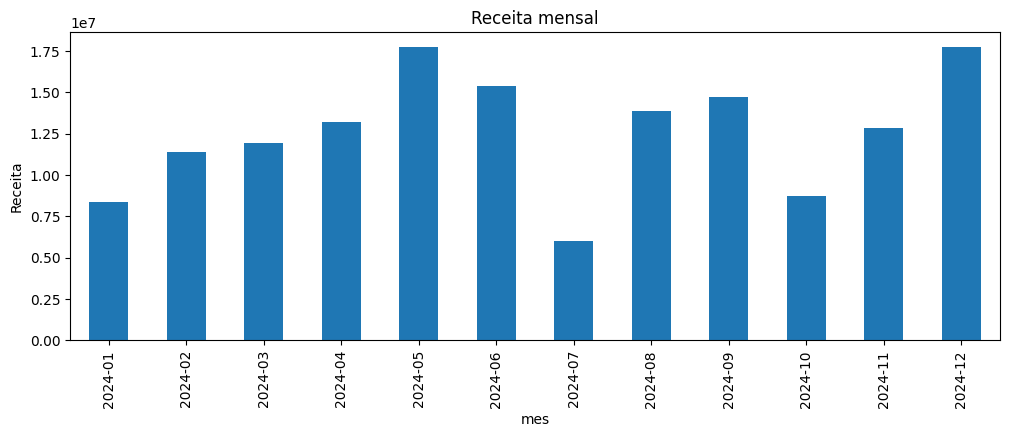

In [ ]:
receita_mensal.plot(kind='bar', figsize=(12,4), title='Receita mensal')
plt.ylabel('Receita')
plt.show()

## 14. A última milha: interpretação

Na aula, vimos que um analista não entrega apenas tabela — entrega **decisão**.

### Questão 12
Com base nos resultados do notebook, escreva interpretações gerenciais para:
1. O produto mais lucrativo
2. O estado com maior receita
3. O canal com maior lucro
4. Um possível problema de qualidade encontrado


#Resposta:

### Produto mais lucrativo:
#### Produtos como Notebook Pro se destacam, indicando que itens de maior valor agregado são os que mais contribuem para o lucro.

### Estado com maior receita:
#### SP lidera em receita, mostrando ser o mercado mais importante para a empresa.

### Canal com maior lucro:
#### Os dados mostram Online e Marketplace no topo, mas com valores infinitos, indicando problema de qualidade. Considerando dados confiáveis, Loja Física se destaca.

### Problema de qualidade:
#### Foram encontrados valores inconsistentes como "inf" no lucro, além de categorias duplicadas (ex: online, ONLINE), o que pode distorcer a análise.

## 15. Desafio extra (opcional)

Faça uma limpeza adicional do dataset:
- padronize valores de `canal` (`online`, `ONLINE`, `MarketPlace`, etc.)
- padronize `estado` (`rj` -> `RJ`)
- substitua infinitos em `lucro_num` por `NaN`
- trate valores ausentes como julgar adequado

Depois gere novamente os rankings e compare os resultados.


In [ ]:
df_dash['lucro_num'] = pd.to_numeric(df_dash['lucro'], errors='coerce')

# 1
df_dash['canal'] = df_dash['canal'].str.lower()

# 2
df_dash['estado'] = df_dash['estado'].str.upper()

# 3
df_dash['lucro_num'] = df_dash['lucro_num'].replace([np.inf, -np.inf], np.nan)

# 4
df_dash['lucro_num'] = df_dash['lucro_num'].fillna(df_dash['lucro_num'].mean())
df_dash['estado'] = df_dash['estado'].fillna('DESCONHECIDO')

In [ ]:
# novo ranking após limpeza
ranking_estados_limpo = df_dash.groupby('estado')['vendas_num'].sum().sort_values(ascending=False)
ranking_canais_limpo = df_dash.groupby('canal')['lucro_num'].sum().sort_values(ascending=False)

ranking_estados_limpo, ranking_canais_limpo

(estado
 SP              23403073.80
 BA              20158371.00
 PE              18892544.00
 ES              18574418.00
 GO              14113942.00
 PR              13521454.00
 RJ              13285417.00
 SC              11724060.00
 MG               9848069.17
 RS               8334753.60
 DESCONHECIDO       92685.00
 Name: vendas_num, dtype: float64,
 canal
 online         208726.053214
 loja física    185020.380000
 marketplace    183641.013214
 Name: lucro_num, dtype: float64)

#### Após a limpeza, os rankings ficam mais confiáveis, pois removemos inconsistências e valores incorretos.

#### Isso permite uma análise mais precisa para tomada de decisão.

## 16. Entrega esperada

Seu notebook deve demonstrar:
- organização
- comentários explicativos
- código legível
- interpretação de negócio

### Fechamento
Ao terminar, salve o notebook com suas respostas e envie junto com o arquivo CSV utilizado.
